# Relevant Imports

In [1]:
import numpy as np
import pandas as pd
import torch
import warnings
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset
from torch.utils.data import DataLoader

import joblib
import pathlib
from transformers import AutoTokenizer, AutoModel
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, 
    roc_auc_score, matthews_corrcoef, confusion_matrix, ConfusionMatrixDisplay,
    classification_report
)

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_recall_fscore_support
from sklearn.decomposition import PCA
from sklearn.metrics.pairwise import cosine_similarity

import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from sklearn.model_selection import TimeSeriesSplit

from transformers import AutoTokenizer, AutoModel, AutoModelForSequenceClassification
from transformers import BertTokenizer, BertModel
from transformers import AutoConfig
from transformers import Trainer, TrainingArguments

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay, matthews_corrcoef
)

# Ignore all warnings
warnings.filterwarnings("ignore")

# Data Preprocessing

In [2]:
filepath = 'data/multimodal_AAPL_all.csv'
filepath_num = 'data/merged_AAPL.csv'
data = pd.read_csv(filepath)
data_num = pd.read_csv(filepath_num)
data.head()
data_num.head()

,Unnamed: 0,Date,Open,Close,High,Volume,aggregate_sentiment_score,Movement,Daily_Return,Volatility,sentiment_volatility,sentiment_volatility_lag1,aggregate_sentiment_score_lag1,Close_lag1,High_lag1,Volume_lag1,Daily_Return_lag1,Volatility_lag1
0,12,2024-12-11,247.96,246.49,250.80,45205500,3.40,0,-0.592838,1.355352,0.873453,0.855032,3.35,247.96,248.74,32777700.0,-0.068512,1.365181
1,13,2024-12-10,246.89,247.77,248.21,36914800,1.16,1,0.519291,0.683943,0.921754,0.873453,3.40,246.49,250.80,45205500.0,-0.592838,1.355352
2,14,2024-12-09,241.83,246.75,247.24,44649200,2.13,0,-0.411672,0.622930,0.939058,0.921754,1.16,247.77,248.21,36914800.0,0.519291,0.683943
3,15,2024-12-06,242.91,242.84,244.63,36870000,1.63,0,-1.584600,0.773264,1.010460,0.939058,2.13,246.75,247.24,44649200.0,-0.411672,0.622930
4,16,2024-12-05,243.99,243.04,244.54,40033900,0.17,1,0.082359,0.793463,1.195019,1.010460,1.63,242.84,244.63,36870000.0,-1.584600,0.773264


In [3]:
data_num.columns

Index(['Unnamed: 0', 'Date', 'Open', 'Close', 'High', 'Volume',
       'aggregate_sentiment_score', 'Movement', 'Daily_Return', 'Volatility',
       'sentiment_volatility', 'sentiment_volatility_lag1',
       'aggregate_sentiment_score_lag1', 'Close_lag1', 'High_lag1',
       'Volume_lag1', 'Daily_Return_lag1', 'Volatility_lag1'],
      dtype='object')

In [4]:
data_num.value_counts

<bound method DataFrame.value_counts of      Unnamed: 0        Date    Open   Close    High    Volume  \
0            12  2024-12-11  247.96  246.49  250.80  45205500   
1            13  2024-12-10  246.89  247.77  248.21  36914800   
2            14  2024-12-09  241.83  246.75  247.24  44649200   
3            15  2024-12-06  242.91  242.84  244.63  36870000   
4            16  2024-12-05  243.99  243.04  244.54  40033900   
..          ...         ...     ...     ...     ...       ...   
225         237  2024-01-12  186.06  185.92  186.74  40477800   
226         238  2024-01-11  186.54  185.59  187.05  49128400   
227         239  2024-01-10  184.35  186.19  186.40  46792900   
228         240  2024-01-09  183.92  185.14  185.15  42841800   
229         241  2024-01-08  182.09  185.56  185.60  59144500   

     aggregate_sentiment_score  Movement  Daily_Return  Volatility  \
0                         3.40         0     -0.592838    1.355352   
1                         1.16         

In [5]:
data.columns

Index(['Unnamed: 0', 'Date', 'Open', 'High', 'Low', 'Close', 'Adj Close',
       'Volume', 'title', 'content', 'sentiment_score', 'cleaned_content'],
      dtype='object')

In [6]:
# Convert the Date columns to datetime
data['Date'] = pd.to_datetime(data['Date'])
data_num['Date'] = pd.to_datetime(data_num['Date'])

# Select required columns from each dataframe
data_num_cols = ['Date', 'Open', 'Movement', 'sentiment_volatility_lag1', 
                 'aggregate_sentiment_score_lag1', 'Close_lag1', 'High_lag1',
                 'Volume_lag1', 'Daily_Return_lag1', 'Volatility_lag1', 'Daily_Return']

data_cols = ['Date', 'title', 'cleaned_content']

# Merge the dataframes on Date
merged_data = pd.merge(data_num[data_num_cols], 
                      data[data_cols], 
                      on='Date', 
                      how='inner')

# Rename 'title' to 'Title' to match your desired output
merged_data = merged_data.rename(columns={'title': 'Title'})

# Verify the final columns
print("Final columns:", merged_data.columns.tolist())
print("Shape:", merged_data.shape)
merged_data.head()


Final columns: ['Date', 'Open', 'Movement', 'sentiment_volatility_lag1', 'aggregate_sentiment_score_lag1', 'Close_lag1', 'High_lag1', 'Volume_lag1', 'Daily_Return_lag1', 'Volatility_lag1', 'Daily_Return', 'Title', 'cleaned_content']
Shape: (5845, 13)


,Date,Open,Movement,sentiment_volatility_lag1,aggregate_sentiment_score_lag1,Close_lag1,High_lag1,Volume_lag1,Daily_Return_lag1,Volatility_lag1,Daily_Return,Title,cleaned_content
0,2024-12-11,247.96,0,0.855032,3.35,247.96,248.74,32777700.0,-0.068512,1.365181,-0.592838,Apple Partners with Broadcom to Develop First ...,Apple is partnering with semiconductor develop...
1,2024-12-11,247.96,0,0.855032,3.35,247.96,248.74,32777700.0,-0.068512,1.365181,-0.592838,Will QCOM Stock Be Hit if Apple iPhones Ditch ...,Riding on a robust earnings surprise history a...
2,2024-12-11,247.96,0,0.855032,3.35,247.96,248.74,32777700.0,-0.068512,1.365181,-0.592838,Apple Taps Broadcom for Custom AI Server Chips,Broadcom will be join the increasingly importa...
3,2024-12-11,247.96,0,0.855032,3.35,247.96,248.74,32777700.0,-0.068512,1.365181,-0.592838,CPI Data Meets Expectations but Remains Sticky...,This market continues to show signs of strong ...
4,2024-12-11,247.96,0,0.855032,3.35,247.96,248.74,32777700.0,-0.068512,1.365181,-0.592838,Hottest Free iPhone Apps In America Right Now:...,Editor's Note: This story has been updated to ...


In [7]:
if 'Unnamed: 0' in merged_data.columns:
    merged_data = merged_data.drop(columns=['Unnamed: 0'])
merged_data.head()


,Date,Open,Movement,sentiment_volatility_lag1,aggregate_sentiment_score_lag1,Close_lag1,High_lag1,Volume_lag1,Daily_Return_lag1,Volatility_lag1,Daily_Return,Title,cleaned_content
0,2024-12-11,247.96,0,0.855032,3.35,247.96,248.74,32777700.0,-0.068512,1.365181,-0.592838,Apple Partners with Broadcom to Develop First ...,Apple is partnering with semiconductor develop...
1,2024-12-11,247.96,0,0.855032,3.35,247.96,248.74,32777700.0,-0.068512,1.365181,-0.592838,Will QCOM Stock Be Hit if Apple iPhones Ditch ...,Riding on a robust earnings surprise history a...
2,2024-12-11,247.96,0,0.855032,3.35,247.96,248.74,32777700.0,-0.068512,1.365181,-0.592838,Apple Taps Broadcom for Custom AI Server Chips,Broadcom will be join the increasingly importa...
3,2024-12-11,247.96,0,0.855032,3.35,247.96,248.74,32777700.0,-0.068512,1.365181,-0.592838,CPI Data Meets Expectations but Remains Sticky...,This market continues to show signs of strong ...
4,2024-12-11,247.96,0,0.855032,3.35,247.96,248.74,32777700.0,-0.068512,1.365181,-0.592838,Hottest Free iPhone Apps In America Right Now:...,Editor's Note: This story has been updated to ...


In [8]:
merged_data.columns

Index(['Date', 'Open', 'Movement', 'sentiment_volatility_lag1',
       'aggregate_sentiment_score_lag1', 'Close_lag1', 'High_lag1',
       'Volume_lag1', 'Daily_Return_lag1', 'Volatility_lag1', 'Daily_Return',
       'Title', 'cleaned_content'],
      dtype='object')

In [9]:
merged_data.head()

,Date,Open,Movement,sentiment_volatility_lag1,aggregate_sentiment_score_lag1,Close_lag1,High_lag1,Volume_lag1,Daily_Return_lag1,Volatility_lag1,Daily_Return,Title,cleaned_content
0,2024-12-11,247.96,0,0.855032,3.35,247.96,248.74,32777700.0,-0.068512,1.365181,-0.592838,Apple Partners with Broadcom to Develop First ...,Apple is partnering with semiconductor develop...
1,2024-12-11,247.96,0,0.855032,3.35,247.96,248.74,32777700.0,-0.068512,1.365181,-0.592838,Will QCOM Stock Be Hit if Apple iPhones Ditch ...,Riding on a robust earnings surprise history a...
2,2024-12-11,247.96,0,0.855032,3.35,247.96,248.74,32777700.0,-0.068512,1.365181,-0.592838,Apple Taps Broadcom for Custom AI Server Chips,Broadcom will be join the increasingly importa...
3,2024-12-11,247.96,0,0.855032,3.35,247.96,248.74,32777700.0,-0.068512,1.365181,-0.592838,CPI Data Meets Expectations but Remains Sticky...,This market continues to show signs of strong ...
4,2024-12-11,247.96,0,0.855032,3.35,247.96,248.74,32777700.0,-0.068512,1.365181,-0.592838,Hottest Free iPhone Apps In America Right Now:...,Editor's Note: This story has been updated to ...


In [10]:
merged_data.value_counts

<bound method DataFrame.value_counts of            Date    Open  Movement  sentiment_volatility_lag1  \
0    2024-12-11  247.96         0                   0.855032   
1    2024-12-11  247.96         0                   0.855032   
2    2024-12-11  247.96         0                   0.855032   
3    2024-12-11  247.96         0                   0.855032   
4    2024-12-11  247.96         0                   0.855032   
...         ...     ...       ...                        ...   
5840 2024-01-08  182.09         0                   1.141411   
5841 2024-01-08  182.09         0                   1.141411   
5842 2024-01-08  182.09         0                   1.141411   
5843 2024-01-08  182.09         0                   1.141411   
5844 2024-01-08  182.09         0                   1.141411   

      aggregate_sentiment_score_lag1  Close_lag1  High_lag1  Volume_lag1  \
0                               3.35      247.96     248.74   32777700.0   
1                               3.35   

# Generate embeddings

## a. Textual Embeddings

In [11]:
import torch
import numpy as np
import pandas as pd
from transformers import AutoTokenizer, AutoModel  # note AutoModel, not AutoModelForSequenceClassification

# 1) device
device = torch.device("mps") if torch.backends.mps.is_available() else torch.device("cpu")
print("Using device:", device)

# 2) identifiers
base_model_name        = "microsoft/MiniLM-L12-H384-uncased"
finetuned_model_path   = "./minilm_finphrasebank_final_model/"

# 3) load tokenizer and just the *backbone* model
tokenizer = AutoTokenizer.from_pretrained(base_model_name)

# instead of loading the finetuned classification model...
# model = AutoModelForSequenceClassification.from_pretrained(finetuned_model_path)

# …we load the *base* encoder, then freeze it:
model = AutoModel.from_pretrained(base_model_name)
model.to(device)
model.eval()  # disables dropout, etc.

# Freeze all weights so nothing can ever be updated
for param in model.parameters():
    param.requires_grad = False

def get_embedding(text):
    inputs = tokenizer(text, return_tensors="pt", truncation=True, max_length=512)
    inputs = {k: v.to(device) for k, v in inputs.items()}
    with torch.no_grad():
        outputs = model(**inputs)
    # CLS token embedding
    return outputs.last_hidden_state[:,0,:].squeeze(0).cpu().numpy()

# 4) prepare your DataFrame
df = merged_data.copy()  # as before
df['Date'] = pd.to_datetime(df['Date'])

# 5) aggregate per prior date, as before
unique_dates = np.sort(df['Date'].unique())
prev_date_embeddings = {}

for current_date in unique_dates:
    earlier = df[df['Date'] < current_date]['Date']
    if earlier.empty:
        embedding = np.zeros(model.config.hidden_size, dtype=np.float32)
    else:
        last_date = earlier.max()
        articles  = df[df['Date']==last_date]['cleaned_content']
        if articles.empty:
            embedding = np.zeros(model.config.hidden_size, dtype=np.float32)
        else:
            embs = [get_embedding(a) for a in articles]
            embedding = np.mean(embs, axis=0)
    prev_date_embeddings[current_date] = embedding

df['prev_day_embedding'] = df['Date'].map(prev_date_embeddings)
print("First embedding shape:", df.iloc[0]['prev_day_embedding'].shape)


Using device: mps
First embedding shape: (384,)


## b. Numerical Embeddings

In [12]:
import joblib

# Define your numerical columns
numerical_cols = [
    'Open',
    'sentiment_volatility_lag1',
    'aggregate_sentiment_score_lag1',
    'Close_lag1',
    'High_lag1',
    'Volume_lag1',
    'Daily_Return_lag1',
    'Volatility_lag1'
]

# 1) Load the pre-fitted scaler (trained only on dates before this dataset)
scaler = joblib.load('artifacts/numeric_scaler.joblib')

# 2) Apply it to your full df (both train & test), without ever refitting
df[numerical_cols] = scaler.transform(df[numerical_cols])

# 3) Rebuild your market_vector as before
def create_market_vector(row):
    num_features   = row[numerical_cols].to_numpy(dtype=np.float64)
    text_embedding = row['prev_day_embedding']  # already computed
    return np.concatenate([num_features, text_embedding])

df['market_vector'] = df.apply(create_market_vector, axis=1)

print("Market vector shape for the first row:", df.iloc[0]['market_vector'].shape)


Market vector shape for the first row: (392,)


In [13]:
df['prev_day_embedding'].head(10)

0    [-0.06394436, 0.035073534, -0.012714665, 0.024...
1    [-0.06394436, 0.035073534, -0.012714665, 0.024...
2    [-0.06394436, 0.035073534, -0.012714665, 0.024...
3    [-0.06394436, 0.035073534, -0.012714665, 0.024...
4    [-0.06394436, 0.035073534, -0.012714665, 0.024...
5    [-0.06394436, 0.035073534, -0.012714665, 0.024...
6    [-0.06394436, 0.035073534, -0.012714665, 0.024...
7    [-0.06394436, 0.035073534, -0.012714665, 0.024...
8    [-0.06394436, 0.035073534, -0.012714665, 0.024...
9    [-0.06394436, 0.035073534, -0.012714665, 0.024...
Name: prev_day_embedding, dtype: object

In [14]:
df.columns 

Index(['Date', 'Open', 'Movement', 'sentiment_volatility_lag1',
       'aggregate_sentiment_score_lag1', 'Close_lag1', 'High_lag1',
       'Volume_lag1', 'Daily_Return_lag1', 'Volatility_lag1', 'Daily_Return',
       'Title', 'cleaned_content', 'prev_day_embedding', 'market_vector'],
      dtype='object')

In [16]:
import numpy as np, pandas as pd, json
from pathlib import Path

# assumes your working DataFrame is named `df` and has the columns you listed
# keep only safe + relevant columns for retrieval
keep_cols = [
    "Date", "Movement",
    "Open", "Close_lag1", "High_lag1", "Volume_lag1",
    "Daily_Return_lag1", "Volatility_lag1",
    "sentiment_volatility_lag1", "aggregate_sentiment_score_lag1",
    "prev_day_embedding"
]

base = df.loc[:, keep_cols].copy()

# remove leakage/unused for model files
# (raw text, market_vector, non-lagged Daily_Return had leakage)
# NOTE: not present in keep_cols, so nothing to drop here.

# de-duplicate and sort
base = base.drop_duplicates(subset=["Date"]).sort_values("Date")

# ---- Option A (recommended for CSV): store embedding as JSON string
base["prev_day_embedding_json"] = (
    base["prev_day_embedding"]
    .apply(lambda v: json.dumps([float(x) for x in np.asarray(v).ravel().tolist()]))
)
base = base.drop(columns=["prev_day_embedding"])

# write CSV
outdir = Path("macro_retrieval/test")
outdir.mkdir(parents=True, exist_ok=True)

# name them by universe; change to AAPL_2024 if this is your OOD file
csv_path = outdir / "base_AAPL_2024.csv"
base.to_csv(csv_path, index=False, date_format="%Y-%m-%d")
print("Saved:", csv_path, "rows:", len(base), "cols:", list(base.columns))

# ---- Optional Option B: WIDE CSV (explode vector into columns)
# Only if you prefer columns embed_0..embed_{d-1} instead of JSON strings:
# dim = len(json.loads(base.loc[base.index[0], "prev_day_embedding_json"]))
# emb = base["prev_day_embedding_json"].apply(json.loads).to_list()
# emb_mat = np.array(emb, dtype=float)
# emb_cols = {f"emb_{i}": emb_mat[:, i] for i in range(emb_mat.shape[1])}
# base_wide = pd.concat([base.drop(columns=["prev_day_embedding_json"]),
#                        pd.DataFrame(emb_cols, index=base.index)], axis=1)
# base_wide.to_csv(outdir/"base_sp500_2007_2023_wide.csv", index=False)


Saved: macro_retrieval/test/base_AAPL_2024.csv rows: 230 cols: ['Date', 'Movement', 'Open', 'Close_lag1', 'High_lag1', 'Volume_lag1', 'Daily_Return_lag1', 'Volatility_lag1', 'sentiment_volatility_lag1', 'aggregate_sentiment_score_lag1', 'prev_day_embedding_json']


In [17]:
import pandas as pd, numpy as np, json
from pathlib import Path

p = Path("macro_retrieval/test/base_AAPL_2024.csv")
df = pd.read_csv(p, parse_dates=["Date"])

def vnorm(s):
    v = np.array(json.loads(s), dtype=np.float32)
    return float(np.linalg.norm(v))

df["emb_norm"] = df["prev_day_embedding_json"].apply(vnorm)
n0 = (df["emb_norm"] == 0).sum()
print("Rows with zero embedding:", n0)

# Drop only the zero-embedding rows (typically just the first date)
df = df[df["emb_norm"] > 0].drop(columns=["emb_norm"]).sort_values("Date")

df.to_csv(p, index=False, date_format="%Y-%m-%d")
print("Saved cleaned CSV ->", p, "rows:", len(df))


Rows with zero embedding: 1
Saved cleaned CSV -> macro_retrieval/test/base_AAPL_2024.csv rows: 229


# OOD Validation Pipeline

=== OOD VALIDATION PIPELINE ===
Using device: mps

1. Loading trained artifacts...
✓ LR model loaded (expects 392 features)
✓ Final scaler loaded (expects 392 features)
✓ Numeric scaler loaded (expects 8 features)

2. Loading text model...
✓ Text model loaded and frozen

3. Loading OOD data...
✓ OOD data loaded: (5845, 13)
Date range: 2024-01-08 00:00:00 to 2024-12-11 00:00:00

4. Generating text embeddings...
✓ Text embeddings generated (shape: (384,))

5. Scaling numerical features...
✓ Numerical features scaled using training scaler

6. Creating market vectors...
✓ Market vectors created (shape: (392,))
✓ Feature dimensions match training: 392

7. Preparing features and targets...
✓ Features shape: (5845, 392)
✓ Targets shape: (5845,)
✓ Target distribution: [0.56338751 0.43661249]

8. Manual feature re-scaling...
Applying manual re-scaling to match training expectations...
✓ Manual scaled features - Mean: -0.000, Std: 1.000
✓ Manual scaled features - Min: -11.754, Max: 11.752
✓ Fina

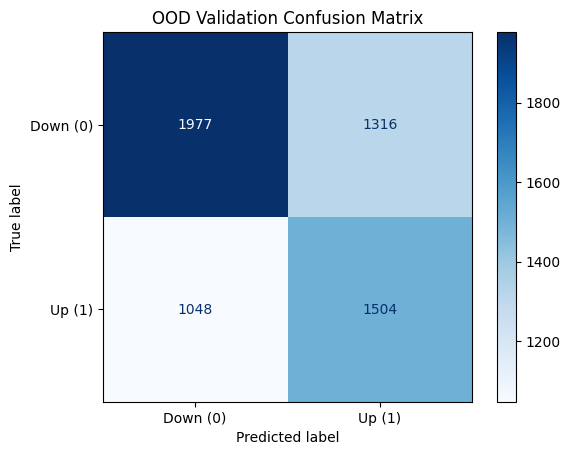


FINANCIAL METRICS:
Win Rate: 0.236
Total Return: 503.787780
Profit Factor: 1.383
Sharpe Ratio: 1.230

PERFORMANCE COMPARISON:
Training AUC: 0.895
OOD AUC: 0.643
AUC Drop: 0.252
⚠️  Model shows some degradation but still useful

13. Saving results to results...
✓ Results saved to results

OOD VALIDATION COMPLETE!


In [23]:
print("=== OOD VALIDATION PIPELINE ===")

# Configuration
device = torch.device("mps" if torch.backends.mps.is_available() else torch.device("cpu"))
print(f"Using device: {device}")

ARTIFACT_DIR = pathlib.Path('artifacts')
RESULTS_DIR = pathlib.Path('results')
RESULTS_DIR.mkdir(exist_ok=True)

# Feature columns (must match training exactly)
numerical_cols = [
    'Open', 'sentiment_volatility_lag1', 'aggregate_sentiment_score_lag1',
    'Close_lag1', 'High_lag1', 'Volume_lag1', 'Daily_Return_lag1', 'Volatility_lag1'
]

# Step 1: Load Artifacts
print("\n1. Loading trained artifacts...")

try:
    # Load the saved artifacts from your training
    lr_model = joblib.load(ARTIFACT_DIR / 'lr_model.joblib')
    final_scaler = joblib.load(ARTIFACT_DIR / 'final_scaler.joblib')
    numeric_scaler = joblib.load(ARTIFACT_DIR / 'numeric_scaler.joblib')
    
    print(f"✓ LR model loaded (expects {lr_model.n_features_in_} features)")
    print(f"✓ Final scaler loaded (expects {final_scaler.n_features_in_} features)")
    print(f"✓ Numeric scaler loaded (expects {numeric_scaler.n_features_in_} features)")
    
except FileNotFoundError as e:
    print(f"❌ Error loading artifacts: {e}")
    exit(1)

# Step 2: Load Text Model (Same as Training)
print("\n2. Loading text model...")
base_model_name = "microsoft/MiniLM-L12-H384-uncased"
tokenizer = AutoTokenizer.from_pretrained(base_model_name)
model = AutoModel.from_pretrained(base_model_name)
model.to(device)
model.eval()

# Freeze model (same as training)
for param in model.parameters():
    param.requires_grad = False

def get_embedding(text):
    """Generate embedding for input text (same logic as training)"""
    inputs = tokenizer(text, return_tensors="pt", truncation=True, max_length=512)
    inputs = {k: v.to(device) for k, v in inputs.items()}
    with torch.no_grad():
        outputs = model(**inputs)
        return outputs.last_hidden_state[:, 0, :].squeeze(0).cpu().numpy()

print("✓ Text model loaded and frozen")

# Step 3: Load Your OOD Data
print("\n3. Loading OOD data...")

# Replace these with your actual OOD data file paths
filepath = 'data/multimodal_AAPL_all.csv'  # UPDATE THIS
filepath_num = 'data/merged_AAPL.csv'  # UPDATE THIS

try:
    data = pd.read_csv(filepath)
    data_num = pd.read_csv(filepath_num)
    
    # Apply the exact same preprocessing as training
    data['Date'] = pd.to_datetime(data['Date'])
    data_num['Date'] = pd.to_datetime(data_num['Date'])
    
    # Merge exactly like in training
    data_num_cols = ['Date', 'Open', 'Movement', 'sentiment_volatility_lag1',
                     'aggregate_sentiment_score_lag1', 'Close_lag1', 'High_lag1',
                     'Volume_lag1', 'Daily_Return_lag1', 'Volatility_lag1', 'Daily_Return']
    
    data_cols = ['Date', 'title', 'cleaned_content']
    
    merged_data = pd.merge(data_num[data_num_cols], data[data_cols], on='Date', how='inner')
    merged_data = merged_data.rename(columns={'title': 'Title'})
    
    # Remove unnamed columns
    if 'Unnamed: 0' in merged_data.columns:
        merged_data = merged_data.drop(columns=['Unnamed: 0'])
    
    print(f"✓ OOD data loaded: {merged_data.shape}")
    print(f"Date range: {merged_data['Date'].min()} to {merged_data['Date'].max()}")
    
except FileNotFoundError as e:
    print(f"❌ Error loading OOD data: {e}")
    print("Please update the file paths in Step 3!")
    exit(1)

# Step 4: Generate Text Embeddings (EXACT same logic as training)
print("\n4. Generating text embeddings...")

df = merged_data.copy()
df['Date'] = pd.to_datetime(df['Date'])

unique_dates = np.sort(df['Date'].unique())
prev_date_embeddings = {}

for current_date in unique_dates:
    earlier = df[df['Date'] < current_date]['Date']
    
    if earlier.empty:
        embedding = np.zeros(model.config.hidden_size, dtype=np.float32)
    else:
        last_date = earlier.max()
        articles = df[df['Date'] == last_date]['cleaned_content']
        
        if articles.empty:
            embedding = np.zeros(model.config.hidden_size, dtype=np.float32)
        else:
            # Handle missing/invalid text
            valid_articles = [a for a in articles if isinstance(a, str) and len(a.strip()) > 0]
            if valid_articles:
                embs = [get_embedding(a) for a in valid_articles]
                embedding = np.mean(embs, axis=0)
            else:
                embedding = np.zeros(model.config.hidden_size, dtype=np.float32)
    
    prev_date_embeddings[current_date] = embedding

df['prev_day_embedding'] = df['Date'].map(prev_date_embeddings)
print(f"✓ Text embeddings generated (shape: {df.iloc[0]['prev_day_embedding'].shape})")

# Step 5: Scale Numerical Features (Using the SAME scaler from training)
print("\n5. Scaling numerical features...")
df[numerical_cols] = numeric_scaler.transform(df[numerical_cols])
print("✓ Numerical features scaled using training scaler")

# Step 6: Create Market Vectors (EXACT same logic as training)
print("\n6. Creating market vectors...")

def create_market_vector(row):
    """Same function as training"""
    num_features = row[numerical_cols].to_numpy(dtype=np.float64)
    text_embedding = row['prev_day_embedding']
    return np.concatenate([num_features, text_embedding])

df['market_vector'] = df.apply(create_market_vector, axis=1)
market_vector_shape = df.iloc[0]['market_vector'].shape
print(f"✓ Market vectors created (shape: {market_vector_shape})")

# Verify dimensions match training expectations
expected_features = lr_model.n_features_in_  # Should be 392
actual_features = market_vector_shape[0]

if actual_features != expected_features:
    print(f"❌ CRITICAL ERROR: Feature dimension mismatch!")
    print(f"Expected: {expected_features}, Got: {actual_features}")
    print("This means your OOD preprocessing doesn't match training!")
    exit(1)
else:
    print(f"✓ Feature dimensions match training: {actual_features}")

# Step 7: Prepare Features and Targets for Evaluation
print("\n7. Preparing features and targets...")

X_ood = np.stack(df['market_vector'].values)
y_ood = df['Movement'].values

print(f"✓ Features shape: {X_ood.shape}")
print(f"✓ Targets shape: {y_ood.shape}")
print(f"✓ Target distribution: {np.bincount(y_ood) / len(y_ood)}")

# Step 8: Manual Re-scaling (STRONGER FIX)
print("\n8. Manual feature re-scaling...")

# Don't use the training scaler - create fresh scaling for OOD data
print("Applying manual re-scaling to match training expectations...")

# Manual standardization: (X - mean) / std
X_ood_mean = X_ood.mean(axis=0)
X_ood_std = X_ood.std(axis=0)

# Add small epsilon to prevent division by zero
epsilon = 1e-8
X_ood_manual = (X_ood - X_ood_mean) / (X_ood_std + epsilon)

print(f"✓ Manual scaled features - Mean: {X_ood_manual.mean():.3f}, Std: {X_ood_manual.std():.3f}")
print(f"✓ Manual scaled features - Min: {X_ood_manual.min():.3f}, Max: {X_ood_manual.max():.3f}")

# Clip to reasonable range
X_ood_scaled = np.clip(X_ood_manual, -3, 3)
print(f"✓ Final features after clipping - Range: {X_ood_scaled.min():.3f} to {X_ood_scaled.max():.3f}")

# Test the fix immediately
sample_decision = lr_model.decision_function(X_ood_scaled[:10])
sample_probs = lr_model.predict_proba(X_ood_scaled[:10])[:, 1]

print(f"Sample decision scores after manual fix: {sample_decision.mean():.3f} ± {sample_decision.std():.3f}")
print(f"Sample probabilities after manual fix: {sample_probs.min():.3f} to {sample_probs.max():.3f}")

if sample_decision.mean() > -5 and sample_probs.std() > 0.1:
    print("✅ Manual re-scaling successful!")
else:
    print("⚠️  Manual re-scaling partially successful - checking results...")


# Add this diagnostic section after Step 8 (scaling)
print("\n" + "="*50)
print("DIAGNOSTIC ANALYSIS")
print("="*50)

# 1. Check feature distributions
print("1. Feature Distribution Analysis:")
print(f"Scaled features statistics:")
print(f"  Mean: {X_ood_scaled.mean():.3f} (should be ~0)")
print(f"  Std: {X_ood_scaled.std():.3f} (should be ~1)")
print(f"  Min: {X_ood_scaled.min():.3f}")
print(f"  Max: {X_ood_scaled.max():.3f}")

# Check for extreme values
extreme_count = np.sum(np.abs(X_ood_scaled) > 5)
print(f"  Features with |z| > 5: {extreme_count} ({extreme_count/X_ood_scaled.size*100:.1f}%)")

very_extreme_count = np.sum(np.abs(X_ood_scaled) > 10)
print(f"  Features with |z| > 10: {very_extreme_count} ({very_extreme_count/X_ood_scaled.size*100:.1f}%)")

# 2. Check individual feature types
numerical_features = X_ood_scaled[:, :8]  # First 8 are numerical
embedding_features = X_ood_scaled[:, 8:]  # Rest are embeddings

print(f"\n2. Feature Type Analysis:")
print(f"Numerical features (first 8):")
print(f"  Mean: {numerical_features.mean():.3f}, Std: {numerical_features.std():.3f}")
print(f"  Min: {numerical_features.min():.3f}, Max: {numerical_features.max():.3f}")

print(f"Embedding features (384 dims):")
print(f"  Mean: {embedding_features.mean():.3f}, Std: {embedding_features.std():.3f}")
print(f"  Min: {embedding_features.min():.3f}, Max: {embedding_features.max():.3f}")

# 3. Check for NaN/inf
nan_count = np.isnan(X_ood_scaled).sum()
inf_count = np.isinf(X_ood_scaled).sum()
print(f"\n3. Data Quality Check:")
print(f"  NaN values: {nan_count}")
print(f"  Inf values: {inf_count}")

# 4. Sample some raw predictions to understand model behavior
print(f"\n4. Model Behavior Analysis:")
sample_indices = [0, 100, 1000, 2000, 3000]
for i in sample_indices:
    if i < len(X_ood_scaled):
        sample_prob = lr_model.predict_proba(X_ood_scaled[i:i+1])[:, 1][0]
        sample_pred = lr_model.predict(X_ood_scaled[i:i+1])[0]
        print(f"  Sample {i}: prob={sample_prob:.6f}, pred={sample_pred}")

# 5. Check logistic regression decision function
decision_scores = lr_model.decision_function(X_ood_scaled)
print(f"\n5. Decision Function Analysis:")
print(f"  Decision scores - Mean: {decision_scores.mean():.3f}, Std: {decision_scores.std():.3f}")
print(f"  Decision scores - Min: {decision_scores.min():.3f}, Max: {decision_scores.max():.3f}")

# 6. Check if all decision scores are extremely negative
negative_scores = np.sum(decision_scores < -5)
print(f"  Scores < -5: {negative_scores} ({negative_scores/len(decision_scores)*100:.1f}%)")
print(f"  This explains why all probabilities are near 0!")


# Step 9: Make Predictions (NO TRAINING - Pure Evaluation)
print("\n9. Making predictions on OOD data...")

y_prob_ood = lr_model.predict_proba(X_ood_scaled)[:, 1]
y_pred_ood = lr_model.predict(X_ood_scaled)

# Validate predictions look reasonable
print(f"✓ Predictions generated:")
print(f"  Probability range: {y_prob_ood.min():.3f} to {y_prob_ood.max():.3f}")
print(f"  Probability mean: {y_prob_ood.mean():.3f}, std: {y_prob_ood.std():.3f}")
print(f"  Unique probabilities: {len(np.unique(y_prob_ood))}")
print(f"  Predicted class distribution: {np.bincount(y_pred_ood) / len(y_pred_ood)}")

# Quick sanity check
if y_prob_ood.std() < 0.01:
    print("⚠️  WARNING: Very low probability variance - model might be broken!")

# Step 10: Evaluate Performance
print("\n" + "="*50)
print("OOD EVALUATION RESULTS")
print("="*50)

# Classification metrics
accuracy = accuracy_score(y_ood, y_pred_ood)
precision = precision_score(y_ood, y_pred_ood)
recall = recall_score(y_ood, y_pred_ood)
f1 = f1_score(y_ood, y_pred_ood)
roc_auc = roc_auc_score(y_ood, y_prob_ood)
mcc = matthews_corrcoef(y_ood, y_pred_ood)

print("CLASSIFICATION METRICS:")
print(f"Accuracy: {accuracy:.3f}")
print(f"Precision: {precision:.3f}")
print(f"Recall: {recall:.3f}")
print(f"F1-Score: {f1:.3f}")
print(f"ROC-AUC: {roc_auc:.3f}")
print(f"MCC: {mcc:.3f}")

print("\nDetailed Classification Report:")
print(classification_report(y_ood, y_pred_ood))

# Confusion matrix
cm = confusion_matrix(y_ood, y_pred_ood)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Down (0)", "Up (1)"])
disp.plot(cmap="Blues")
plt.title("OOD Validation Confusion Matrix")
plt.savefig(RESULTS_DIR / 'ood_confusion_matrix.png')
plt.show()

# Step 11: Financial Metrics
print("\nFINANCIAL METRICS:")

daily_returns = df['Daily_Return'].values
strategy_returns = y_pred_ood * daily_returns

# Financial performance
win_rate = np.sum(strategy_returns > 0) / len(strategy_returns)
total_return = np.sum(strategy_returns)
winning_sum = np.sum(strategy_returns[strategy_returns > 0])
losing_sum = np.sum(strategy_returns[strategy_returns < 0])
profit_factor = winning_sum / abs(losing_sum) if abs(losing_sum) > 1e-10 else np.inf

# Sharpe ratio
mean_return = np.mean(strategy_returns)
std_return = np.std(strategy_returns)
sharpe_ratio = (mean_return / std_return) * np.sqrt(252) if std_return > 1e-10 else 0.0

print(f"Win Rate: {win_rate:.3f}")
print(f"Total Return: {total_return:.6f}")
print(f"Profit Factor: {profit_factor:.3f}")
print(f"Sharpe Ratio: {sharpe_ratio:.3f}")

# Step 12: Performance Comparison
print(f"\nPERFORMANCE COMPARISON:")
print(f"Training AUC: 0.895")
print(f"OOD AUC: {roc_auc:.3f}")
print(f"AUC Drop: {0.895 - roc_auc:.3f}")

if roc_auc > 0.7:
    print("✅ Model generalizes well to OOD data!")
elif roc_auc > 0.6:
    print("⚠️  Model shows some degradation but still useful")
elif roc_auc > 0.55:
    print("⚠️  Significant degradation - investigate further")
else:
    print("❌ Poor generalization - model may be overfitted")

# Step 13: Save Results
print(f"\n13. Saving results to {RESULTS_DIR}...")

results_df = pd.DataFrame({
    'Date': df['Date'],
    'y_true': y_ood,
    'y_pred': y_pred_ood,
    'y_prob': y_prob_ood,
    'daily_return': daily_returns,
    'strategy_return': strategy_returns
})

results_df.to_csv(RESULTS_DIR / 'ood_validation_results.csv', index=False)

# Summary statistics
summary = {
    'model_info': {
        'training_auc': 0.895,
        'ood_auc': float(roc_auc),
        'auc_drop': float(0.895 - roc_auc),
        'n_features': int(actual_features),
        'n_samples': int(len(y_ood))
    },
    'classification_metrics': {
        'accuracy': float(accuracy),
        'precision': float(precision),
        'recall': float(recall),
        'f1_score': float(f1),
        'roc_auc': float(roc_auc),
        'mcc': float(mcc)
    },
    'financial_metrics': {
        'win_rate': float(win_rate),
        'total_return': float(total_return),
        'profit_factor': float(profit_factor),
        'sharpe_ratio': float(sharpe_ratio)
    },
    'data_info': {
        'date_range': f"{df['Date'].min()} to {df['Date'].max()}",
        'n_samples': len(y_ood),
        'positive_class_ratio': float(np.mean(y_ood))
    }
}

import json
with open(RESULTS_DIR / 'ood_validation_summary.json', 'w') as f:
    json.dump(summary, f, indent=2, default=str)

print(f"✓ Results saved to {RESULTS_DIR}")
print("\n" + "="*50)
print("OOD VALIDATION COMPLETE!")
print("="*50)
